In [60]:
!pip install -r ../requirements.txt

Defaulting to user installation because normal site-packages is not writeable


In [61]:
!prefect version

Version:              3.7.2
API version:          0.8.4
Python version:       3.13.3
Git commit:           5836855e
Built:                Sat, May 23, 2026 12:23 AM
OS/Arch:              win32/AMD64
Profile:              ephemeral
Server type:          ephemeral
Pydantic version:     2.13.1
Server:
  Database:           sqlite
  SQLite version:     3.49.1


Since prefect version 3.7.2 does not allow me to try cloud variant so moving to GitHub.

In [1]:
import os
import sys

sys.path.append(os.path.abspath("..")) 
from src.ingestion import *
from src.preprocessing import *
from src.eda import *
from src.train import *
from src.evaluate import *

In [63]:
filePath = "../data/raw/loan_prediction_dataset.csv"

df = load_data(filePath)
dataset_overview(df)

Dataset Loaded Successfully
Shape: (2000, 7)
The dataset has total 0 missing values.

Columns:
['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term', 'Employment_Status', 'Loan_Approved']

Data Types:
Age                   int64
Income                int64
Credit_Score          int64
Loan_Amount           int64
Loan_Term             int64
Employment_Status    object
Loan_Approved         int64
dtype: object

First 5 Rows:
   Age  Income  Credit_Score  Loan_Amount  Loan_Term Employment_Status  \
0   56   81788           334        15022         48          Employed   
1   69  102879           781        21013         24     Self-Employed   
2   46   58827           779        39687         60     Self-Employed   
3   32  127188           364        16886         24        Unemployed   
4   60   25655           307        26256         36        Unemployed   

   Loan_Approved  
0              0  
1              1  
2              0  
3              0  
4              0  


In [3]:
check_missing_values(df)


Missing Values:
Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Loan_Approved        0
dtype: int64


Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Loan_Approved        0
dtype: int64

In [4]:
encoded_df = encode_categorical(df)

In [5]:
features_df = create_features(encoded_df)

In [6]:
processed_df = normalize_features(features_df)

In [7]:
print("\nProcessed DataFrame:")
print(processed_df.head())


Processed DataFrame:
        Age    Income  Credit_Score  Loan_Amount  Loan_Term  \
0  0.745098  0.474695      0.061931     0.285323       0.75   
1  1.000000  0.637137      0.876138     0.407753       0.25   
2  0.549020  0.297850      0.872495     0.789369       1.00   
3  0.274510  0.824364      0.116576     0.323415       0.25   
4  0.823529  0.042361      0.012750     0.514898       0.50   

   Employment_Status  Loan_Approved  Income_Per_Loan  Loan_Burden  
0                0.0              0         0.040088     0.076916  
1                0.5              1         0.035697     0.085926  
2                0.5              0         0.008373     0.291857  
3                1.0              0         0.056798     0.054630  
4                1.0              0         0.004329     0.444551  


In [8]:
summary_statistics(processed_df)


Summary Statistics
               Age       Income  Credit_Score  Loan_Amount    Loan_Term  \
count  2000.000000  2000.000000   2000.000000  2000.000000  2000.000000   
mean      0.505990     0.495842      0.504654     0.498637     0.489125   
std       0.292729     0.290912      0.286933     0.288485     0.353872   
min       0.000000     0.000000      0.000000     0.000000     0.000000   
25%       0.254902     0.236991      0.255009     0.253081     0.250000   
50%       0.509804     0.492298      0.507286     0.498345     0.500000   
75%       0.745098     0.749927      0.756375     0.753857     0.750000   
max       1.000000     1.000000      1.000000     1.000000     1.000000   

       Employment_Status  Loan_Approved  Income_Per_Loan  Loan_Burden  
count        2000.000000    2000.000000      2000.000000  2000.000000  
mean            0.278750       0.171000         0.050078     0.172936  
std             0.394336       0.376603         0.084201     0.162704  
min             

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved,Income_Per_Loan,Loan_Burden
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.505990,0.495842,0.504654,0.498637,0.489125,0.278750,0.171000,0.050078,0.172936
std,0.292729,0.290912,0.286933,0.288485,0.353872,0.394336,0.376603,0.084201,0.162704
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.254902,0.236991,0.255009,0.253081,0.250000,0.000000,0.000000,0.012024,0.063915
50%,0.509804,0.492298,0.507286,0.498345,0.500000,0.000000,0.000000,0.023315,0.127228
75%,0.745098,0.749927,0.756375,0.753857,0.750000,0.500000,0.000000,0.048494,0.222356
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


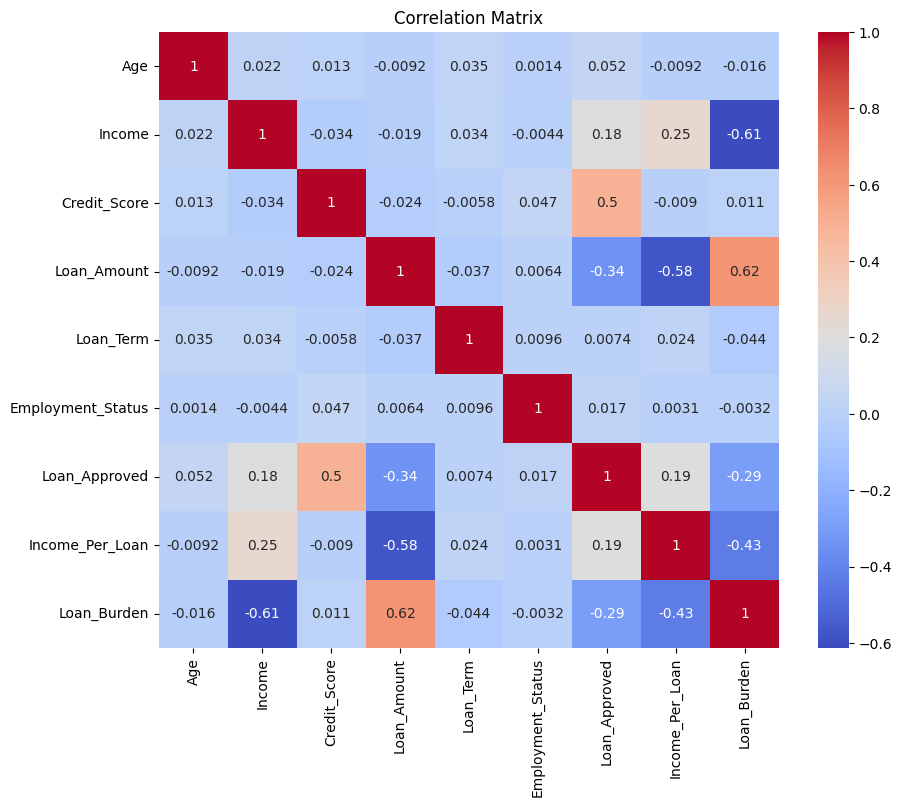

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved,Income_Per_Loan,Loan_Burden
Age,1.000000,0.021820,0.013135,-0.009203,0.034990,0.001439,0.051829,-0.009216,-0.016002
Income,0.021820,1.000000,-0.033512,-0.018823,0.034360,-0.004368,0.182107,0.251030,-0.613424
Credit_Score,0.013135,-0.033512,1.000000,-0.023698,-0.005800,0.047335,0.495666,-0.008959,0.011171
Loan_Amount,-0.009203,-0.018823,-0.023698,1.000000,-0.037309,0.006428,-0.336799,-0.578496,0.621249
Loan_Term,0.034990,0.034360,-0.005800,-0.037309,1.000000,0.009635,0.007392,0.023534,-0.043515
Employment_Status,0.001439,-0.004368,0.047335,0.006428,0.009635,1.000000,0.017407,0.003109,-0.003234
Loan_Approved,0.051829,0.182107,0.495666,-0.336799,0.007392,0.017407,1.000000,0.191955,-0.293743
Income_Per_Loan,-0.009216,0.251030,-0.008959,-0.578496,0.023534,0.003109,0.191955,1.000000,-0.434320
Loan_Burden,-0.016002,-0.613424,0.011171,0.621249,-0.043515,-0.003234,-0.293743,-0.434320,1.000000


In [9]:
correlation_analysis(processed_df)

In [10]:
create_income_bins(processed_df)

Income_Category
Low       680
Medium    663
High      657
Name: count, dtype: int64


,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved,Income_Per_Loan,Loan_Burden,Income_Category
0,0.745098,0.474695,0.061931,0.285323,0.75,0.0,0,0.040088,0.076916,Medium
1,1.000000,0.637137,0.876138,0.407753,0.25,0.5,1,0.035697,0.085926,Medium
2,0.549020,0.297850,0.872495,0.789369,1.00,0.5,0,0.008373,0.291857,Low
3,0.274510,0.824364,0.116576,0.323415,0.25,1.0,0,0.056798,0.054630,High
4,0.823529,0.042361,0.012750,0.514898,0.50,1.0,0,0.004329,0.444551,Low
...,...,...,...,...,...,...,...,...,...,...
1995,0.882353,0.519305,0.839709,0.585605,0.75,0.0,1,0.020099,0.145050,Medium
1996,0.960784,0.055554,0.719490,0.256284,0.50,0.0,0,0.012614,0.214074,Low
1997,1.000000,0.656831,0.612022,0.734827,0.50,0.5,0,0.019306,0.150213,Medium
1998,0.117647,0.739242,0.256831,0.163506,0.75,0.0,0,0.099102,0.030664,High


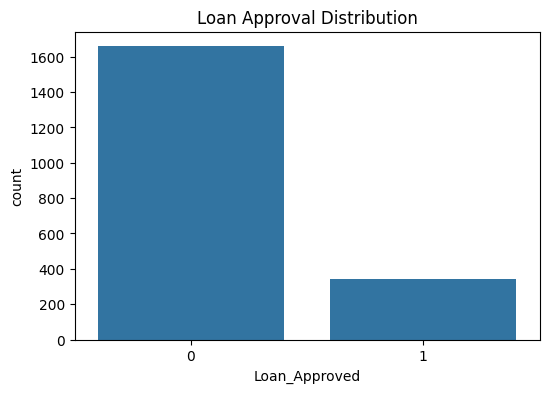

In [11]:
target_distribution(processed_df)

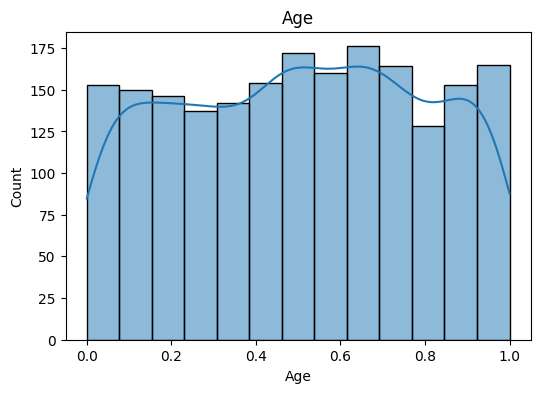

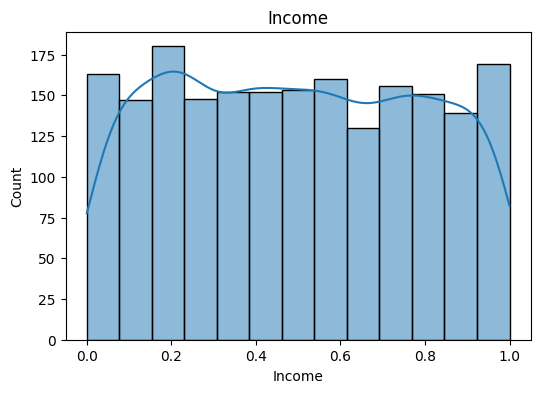

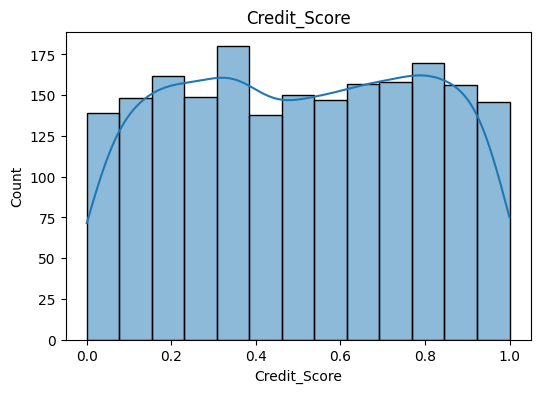

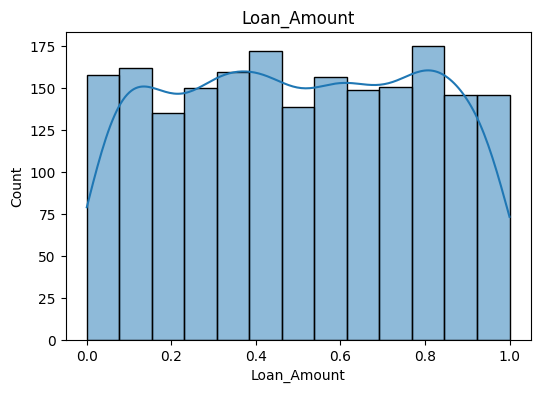

In [12]:
univariate_analysis(processed_df)

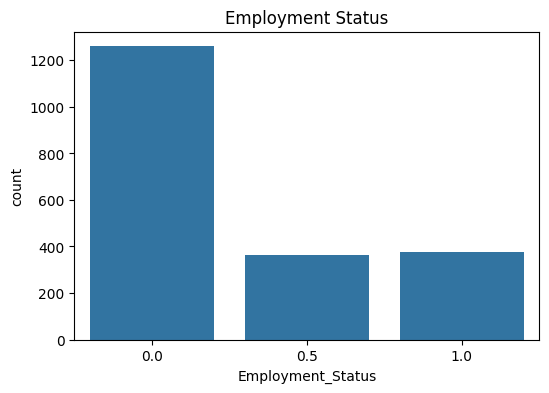

In [13]:
employment_analysis(processed_df)


Summary Statistics
               Age       Income  Credit_Score  Loan_Amount    Loan_Term  \
count  2000.000000  2000.000000   2000.000000  2000.000000  2000.000000   
mean      0.505990     0.495842      0.504654     0.498637     0.489125   
std       0.292729     0.290912      0.286933     0.288485     0.353872   
min       0.000000     0.000000      0.000000     0.000000     0.000000   
25%       0.254902     0.236991      0.255009     0.253081     0.250000   
50%       0.509804     0.492298      0.507286     0.498345     0.500000   
75%       0.745098     0.749927      0.756375     0.753857     0.750000   
max       1.000000     1.000000      1.000000     1.000000     1.000000   

       Employment_Status  Loan_Approved  Income_Per_Loan  Loan_Burden  
count        2000.000000    2000.000000      2000.000000  2000.000000  
mean            0.278750       0.171000         0.050078     0.172936  
std             0.394336       0.376603         0.084201     0.162704  
min             

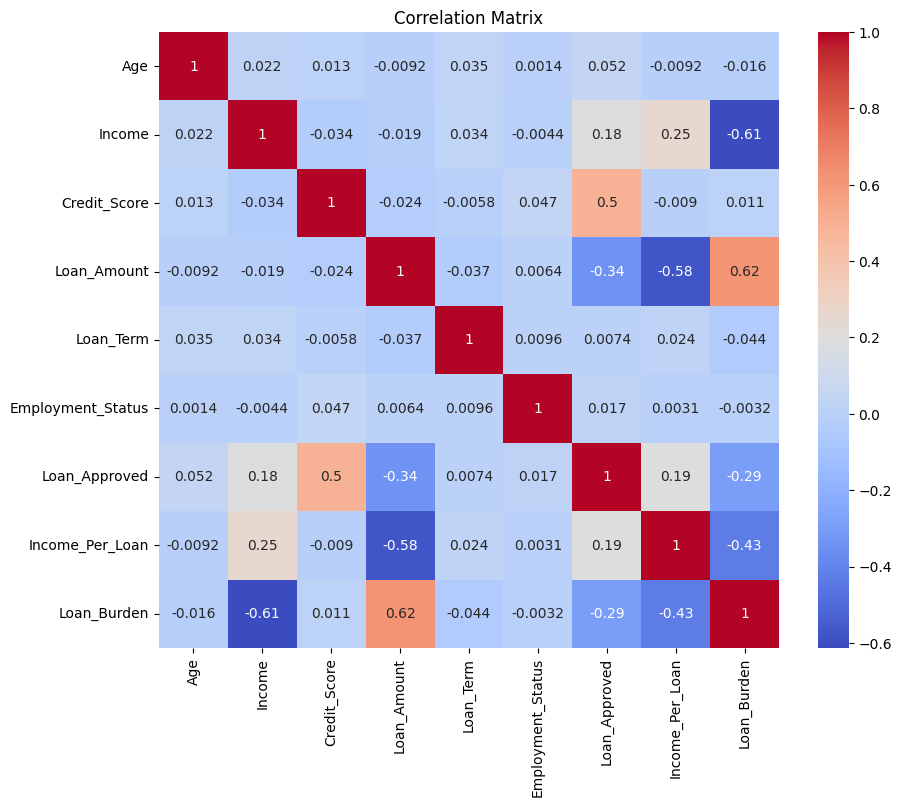

Income_Category
Low       680
Medium    663
High      657
Name: count, dtype: int64


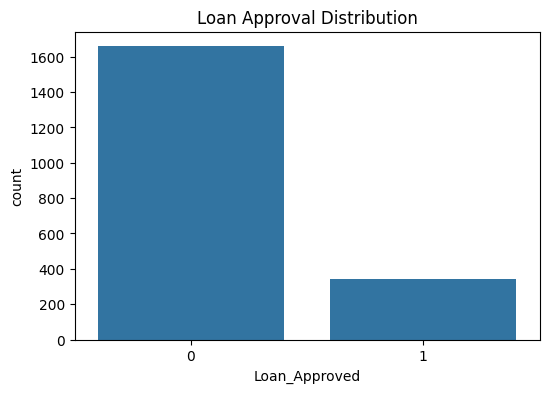

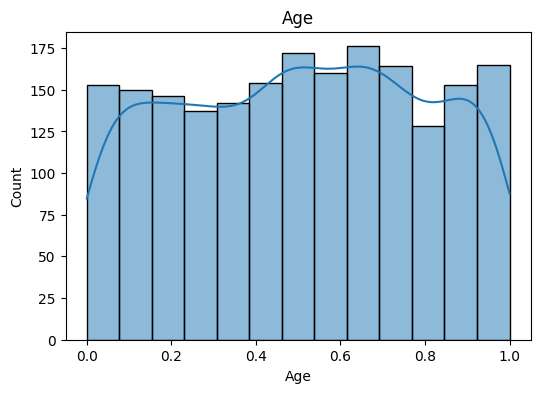

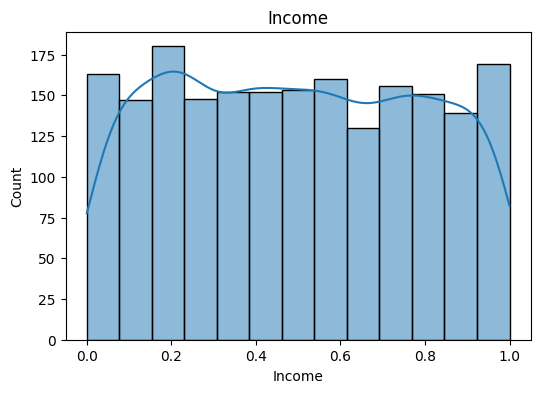

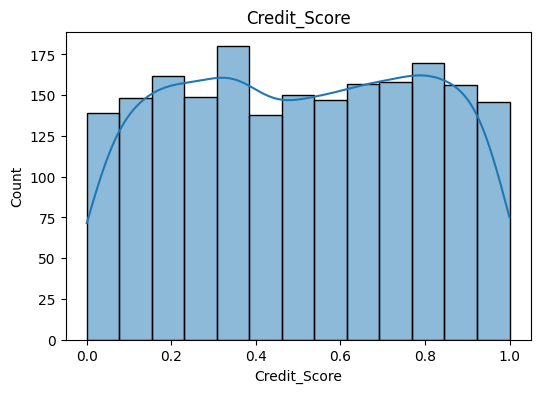

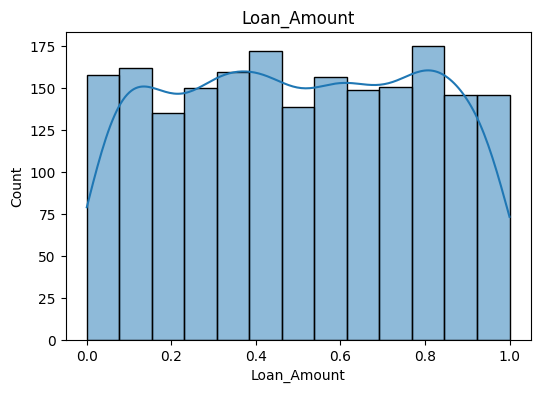

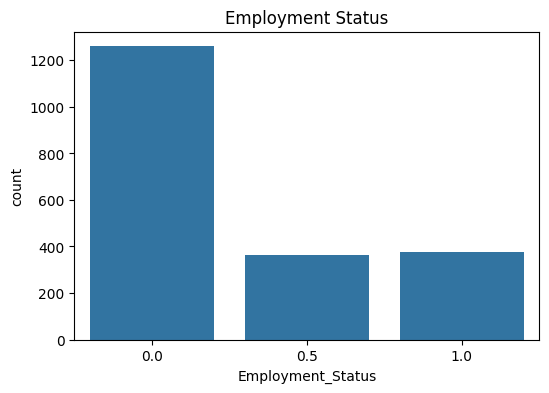

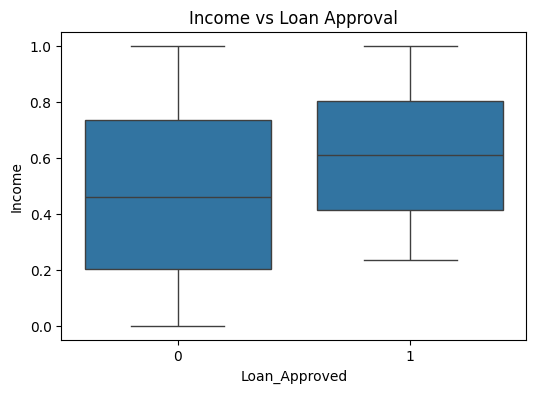

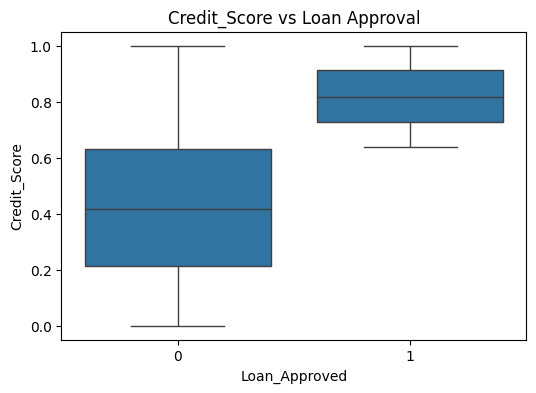

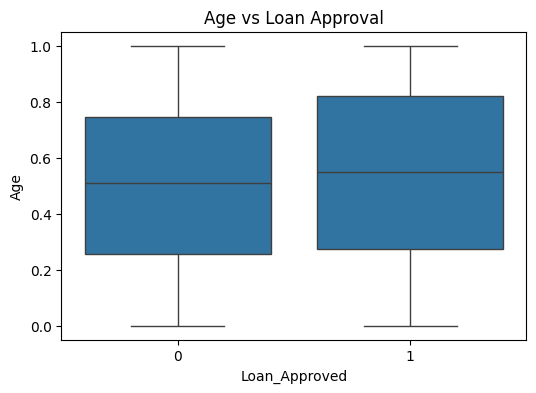

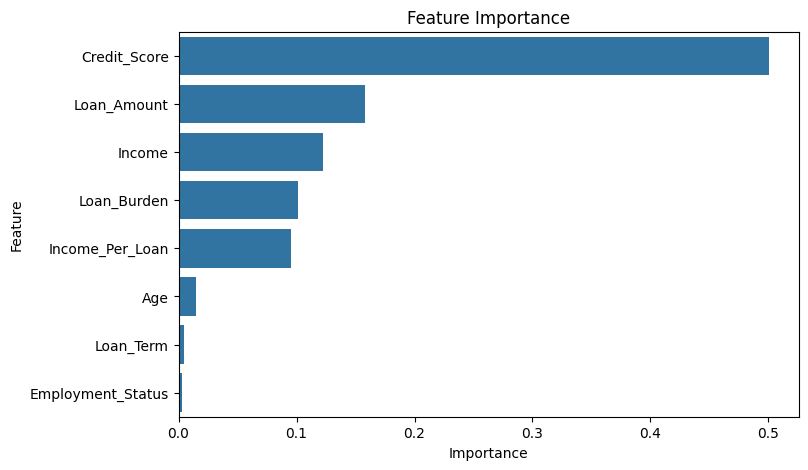

,Feature,Importance
2,Credit_Score,0.500457
3,Loan_Amount,0.158249
1,Income,0.122285
7,Loan_Burden,0.101543
6,Income_Per_Loan,0.095413
0,Age,0.014512
4,Loan_Term,0.004586
5,Employment_Status,0.002954


In [14]:
summary_statistics(processed_df)

correlation_analysis(processed_df)

create_income_bins(processed_df)

target_distribution(processed_df)

univariate_analysis(processed_df)

employment_analysis(processed_df)

bivariate_analysis(processed_df)

feature_importance(processed_df)

In [15]:
(
    X_train,
    X_test,
    y_train,
    y_test
) = prepare_data(processed_df)

In [16]:
print("Train and Test data shapes:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")   

Train and Test data shapes:
X_train: (1400, 8), y_train: (1400,)
X_test: (600, 8), y_test: (600,)


In [17]:
lr_model = train_logistic_regression(
    X_train,
    y_train
)

lr_results = evaluate_model(
    lr_model,
    X_test,
    y_test,
    "Logistic Regression"
)



Logistic Regression
Accuracy : 0.9133
Precision: 0.8312
Recall   : 0.6214
F1 Score : 0.7111


In [18]:
rf_model = train_random_forest(
    X_train,
    y_train
)

rf_results = evaluate_model(
    rf_model,
    X_test,
    y_test,
    "Random Forest"
)



Random Forest
Accuracy : 0.9933
Precision: 1.0000
Recall   : 0.9612
F1 Score : 0.9802


In [19]:
comparison = pd.DataFrame([
    lr_results,
    rf_results
])

comparison

,model,accuracy,precision,recall,f1
0,Logistic Regression,0.913333,0.831169,0.621359,0.711111
1,Random Forest,0.993333,1.000000,0.961165,0.980198
